Notebook 2 - HMM(Hidden Markov Model) Regime Detection

In [1]:
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "data").is_dir() and (ROOT.parent / "data").is_dir():
    ROOT = ROOT.parent
DATA = ROOT / "data"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (14, 5)
np.random.seed(42)

In [3]:
dataset = pd.read_csv(DATA / 'processed' / 'dataset.csv', index_col=0, parse_dates=True)
print(dataset.shape)
print(dataset.columns.tolist())
dataset.head()

(4760, 9)
['SPYlogret', 'TLTlogret', 'GLDlogret', 'CASHlogret', 'VIX', 'YIELDSPREAD', 'UNRATE', 'DGS10', 'CPIYOY']


,SPYlogret,TLTlogret,GLDlogret,CASHlogret,VIX,YIELDSPREAD,UNRATE,DGS10,CPIYOY
Date,,,,,,,,,
2006-02-02,-0.011673,0.001886,0.004926,0.000172,12.36,-0.02,4.7,4.57,4.018789
2006-02-03,-0.004977,0.007071,-0.008460,0.000171,13.23,-0.02,4.7,4.57,4.018789
2006-02-06,0.002610,0.001979,0.003886,0.000171,12.96,-0.05,4.7,4.54,4.018789
2006-02-07,-0.008886,-0.004735,-0.038093,0.000171,13.04,-0.07,4.7,4.55,4.018789
2006-02-08,0.009044,-0.002321,0.004204,0.000172,13.59,-0.04,4.7,4.57,4.018789


In [4]:
SPYvol21d = dataset['SPYlogret'].rolling(21).std() * np.sqrt(252)

features = pd.DataFrame({
    'SPYlogret'     : dataset['SPYlogret'],
    'SPYvol21d' : SPYvol21d,
    'vix'         : dataset['VIX'],
    'yieldspread': dataset['YIELDSPREAD'],
    'unrate'      : dataset['UNRATE'],
})

features = features.dropna()
print(f'Features shape: {features.shape}')
features.describe().round(3)

Features shape: (4740, 5)


,SPYlogret,SPYvol21d,vix,yieldspread,unrate
count,4740.000,4740.000,4740.000,4740.000,4740.000
mean,0.000,0.160,19.550,1.037,5.871
std,0.012,0.113,8.892,0.978,2.190
min,-0.116,0.034,9.140,-1.080,3.400
25%,-0.004,0.093,13.620,0.190,4.100
50%,0.001,0.132,17.120,1.040,5.000
75%,0.006,0.190,22.640,1.770,7.600
max,0.136,0.937,82.690,2.910,14.800


In [5]:
featuresmean = features.mean()
featuresstd  = features.std()
featuresz = (features - featuresmean) / featuresstd

print('After standardization:')
print(featuresz.describe().round(3))

After standardization:
       SPYlogret  SPYvol21d       vix  yieldspread    unrate
count   4740.000   4740.000  4740.000     4740.000  4740.000
mean       0.000     -0.000     0.000        0.000    -0.000
std        1.000      1.000     1.000        1.000     1.000
min       -9.482     -1.113    -1.171       -2.163    -1.128
25%       -0.359     -0.592    -0.667       -0.865    -0.809
50%        0.023     -0.244    -0.273        0.003    -0.398
75%        0.449      0.263     0.348        0.749     0.790
max       11.023      6.876     7.101        1.914     4.078


In [6]:
N = 3
X = featuresz.values

best_model = GaussianHMM(
    n_components=N,
    covariance_type='full',
    n_iter=500,
    random_state=42,
    tol=1e-4,
)
best_model.fit(X)
best_score = best_model.score(X)

print(f'Log-likelihood: {best_score:.2f}')
print(f'Converged: {best_model.monitor_.converged}')

Log-likelihood: -17395.46
Converged: True


We know that the HMM has to identify between three states: Crisis, Recovery, and Bullish. But the model cannot identify the which state means what, and hence we denote them as S0, S1, and S2 for now and will label them later.

In [7]:
print('Transition Matrix')
print(pd.DataFrame(
    best_model.transmat_,
    index=[f'from S{i}' for i in range(N)],
    columns=[f'to S{i}' for i in range(N)]
).round(3))

print()
print('State Means (in standardized units)')
print(pd.DataFrame(
    best_model.means_,
    index=[f'S{i}' for i in range(N)],
    columns=featuresz.columns
).round(3))

Transition Matrix
         to S0  to S1  to S2
from S0  0.995  0.001  0.003
from S1  0.000  0.987  0.013
from S2  0.006  0.021  0.973

State Means (in standardized units)
    SPYlogret  SPYvol21d    vix  yieldspread  unrate
S0      0.042     -0.222 -0.106        0.905   1.041
S1      0.023     -0.460 -0.565       -0.687  -0.719
S2     -0.095      1.078  1.106       -0.006  -0.130


We know the following about the three states we are trying to identify.

- Crisis State :
    - SPYlogret negative (markets falling)
    - SPYvol21d strongly positive (high realised volatility)
    - vix strongly positive (high fear)
    - yieldspread indeterminate (rate cuts can happen during crises)
    - unrate positive (unemployment rising)

- Recovery State :
    - SPYlogret positive (markets rallying off oversold lows)
    - SPYvol21d negative (volatility falling from crisis levels)
    - vix slightly negative (fear subsiding)
    - yieldspread strongly positive (central bank has cut rates aggressively, steep yield curve)
    - unrate strongly positive (unemployment still elevated from prior crisis)

- Bullish State :
    - SPYlogret positive but modest (steady gains)
    - SPYvol21d slightly negative (low calm vol)
    - vix strongly negative (low fear)
    - yieldspread negative or near zero (flat yield curve, late cycle)
    - unrate strongly negative (low unemployment, strong economy)

We can now use the model to identify the states and label them.

In [8]:
means_df = pd.DataFrame(
    best_model.means_,
    columns=featuresz.columns
)

print('Raw State Means')
print(means_df.round(3))
print()

profiles = {
    'crisis': {'SPYlogret': -1, 'SPYvol21d': +1, 'vix': +1, 'unrate': +1},
    'recovery': {'SPYlogret': +1, 'SPYvol21d': -1, 'yieldspread': +1, 'unrate': +1},
    'bull': {'SPYlogret': +1, 'SPYvol21d': -1, 'vix': -1, 'unrate': -1},
}

scores = pd.DataFrame(index=range(3), columns=['crisisscore', 'recoveryscore', 'bullscore'])

for state in range(3):
    for profile_name in profiles:
        profile_score = sum(
            1 if np.sign(means_df.loc[state, feat]) == exp_sign else -1
            for feat, exp_sign in profiles[profile_name].items()
        )
        scores.loc[state, f'{profile_name}score'] = profile_score

scores = scores.astype(int)
print('Profile Match Scores')
print(scores)
print()

crisisstate = scores['crisisscore'].idxmax()
remaining = [s for s in range(3) if s != crisisstate]
recoverystate = scores.loc[remaining, 'recoveryscore'].idxmax()
bullstate = [s for s in remaining if s != recoverystate][0]

print(f'Crisis state    →   S{crisisstate}')
print(f'Recovery state  →   S{recoverystate}')
print(f'Bull state      →   S{bullstate}')

relabel = {crisisstate: 0, recoverystate: 1, bullstate: 2}

Raw State Means
   SPYlogret  SPYvol21d    vix  yieldspread  unrate
0      0.042     -0.222 -0.106        0.905   1.041
1      0.023     -0.460 -0.565       -0.687  -0.719
2     -0.095      1.078  1.106       -0.006  -0.130

Profile Match Scores
   crisisscore  recoveryscore  bullscore
0           -2              4          2
1           -4              0          4
2            2             -4         -2

Crisis state    →   S2
Recovery state  →   S0
Bull state      →   S1


We start by finding state probabilities for each day. But this can not be used to identify the state for each day, there can be days of uncertainity where the probabilities may be close to each other.

To solve this, we can use the Viterbi algorithm to find the most likely state sequence.

In [9]:
rawstateprobs = best_model.predict_proba(X)

stateprobs = np.zeros_like(rawstateprobs)
for old_label, new_label in relabel.items():
    stateprobs[:, new_label] = rawstateprobs[:, old_label]

# We create a clean DataFrame with all this information
regimeprobs = pd.DataFrame(
    stateprobs,
    index=featuresz.index,
    columns=['pcrisis', 'precovery', 'pbull']
)

rawhardstates = best_model.predict(X)
hardstates = np.array([relabel[s] for s in rawhardstates])
regimeprobs['regime'] = hardstates

regimenames = {0: 'Crisis', 1: 'Recovery', 2: 'Bullish'}
regimeprobs['regimename'] = regimeprobs['regime'].map(regimenames)

print(regimeprobs.head(10))
print()
print('Regime distribution:')
print(regimeprobs['regimename'].value_counts())
print()
print(f'Total days: {len(regimeprobs)}')

                  pcrisis      precovery     pbull  regime regimename
Date                                                                 
2006-03-03  4.609133e-279  5.611088e-194  1.000000       2    Bullish
2006-03-06   4.559334e-06   8.574231e-87  0.999995       2    Bullish
2006-03-07   3.659808e-06   2.213707e-12  0.999996       2    Bullish
2006-03-08   3.602368e-06   1.758722e-12  0.999996       2    Bullish
2006-03-09   5.601492e-06   1.991914e-12  0.999994       2    Bullish
2006-03-10   7.482736e-06   3.941397e-12  0.999993       2    Bullish
2006-03-13   3.491825e-06   3.268753e-12  0.999997       2    Bullish
2006-03-14   1.021093e-05   2.526753e-12  0.999990       2    Bullish
2006-03-15   5.297161e-06   5.373029e-12  0.999995       2    Bullish
2006-03-16   3.537738e-06   2.286515e-12  0.999996       2    Bullish

Regime distribution:
regimename
Bullish     2022
Recovery    1547
Crisis      1171
Name: count, dtype: int64

Total days: 4740


We now validate our regimes by comparing it with returns.
Ideally, 
- Crisis state should have negative annualised returns but high annualised volume
- Recovery state should have strongly positive returns (rally off lows) with moderate volatility
- Bull state should have positive returns and low volume

In [10]:
actualspy = dataset['SPYlogret'].reindex(regimeprobs.index)
stats = []
for state_id, name in regimenames.items():
    mask = regimeprobs['regime'] == state_id
    n = mask.sum()
    annualmean = actualspy[mask].mean() * 252 * 100
    annualvol = actualspy[mask].std()  * np.sqrt(252) * 100
    sharpe = annualmean / annualvol if annualvol > 0 else 0
    pcttime = n / len(mask) * 100
    stats.append({
        'regime'       : name,
        'days'         : n,
        'pcttime'     : f'{pcttime:.1f}%',
        'annualreturn%' : round(annualmean, 1),
        'annualvol%'    : round(annualvol, 1),
        'sharpe'       : round(sharpe, 2),
    })

stats_df = pd.DataFrame(stats)
print(stats_df.to_string(index=False))

  regime  days pcttime  annualreturn%  annualvol%  sharpe
  Crisis  1171   24.7%          -19.6        33.0   -0.59
Recovery  1547   32.6%           23.1        13.7    1.69
 Bullish  2022   42.7%           16.9        10.7    1.59


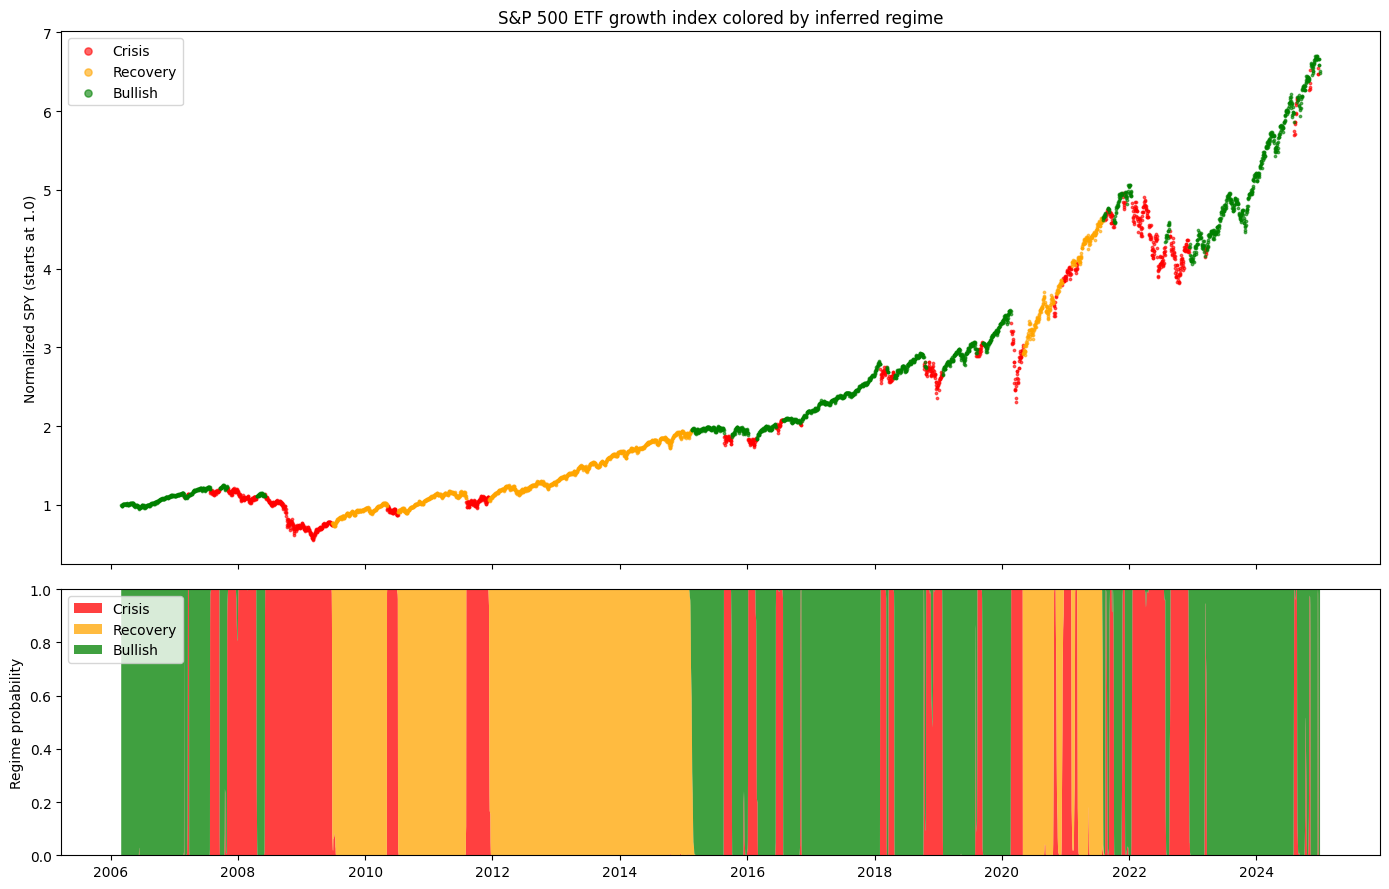

In [11]:
# Plotting the regimes
spy_norm = np.exp(dataset['SPYlogret'].reindex(regimeprobs.index).cumsum())

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

ax_top = axes[0]
colors = {'Crisis': 'red', 'Recovery': 'orange', 'Bullish': 'green'}
for state_id, name in regimenames.items():
    mask = regimeprobs['regime'] == state_id
    ax_top.scatter(
        spy_norm.index[mask], spy_norm[mask],
        c=colors[name], s=3, label=name, alpha=0.6,
    )
ax_top.set_title('S&P 500 ETF growth index colored by inferred regime')
ax_top.set_ylabel('Normalized SPY (starts at 1.0)')
ax_top.legend(loc='upper left', markerscale=3)

ax_bot = axes[1]
ax_bot.stackplot(
    regimeprobs.index,
    regimeprobs['pcrisis'], regimeprobs['precovery'], regimeprobs['pbull'],
    labels=['Crisis', 'Recovery', 'Bullish'],
    colors=['red', 'orange', 'green'],
    alpha=0.75,
)
ax_bot.set_ylabel('Regime probability')
ax_bot.set_ylim(0, 1)
ax_bot.legend(loc='upper left')

ax_bot.xaxis.set_major_locator(mdates.YearLocator(2))
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

In [12]:
regimeprobs.to_csv(DATA / 'processed' / 'regimeprobs.csv')